# Food Choices and Location-Based Lifestyle Analysis
> **An end-to-end Data Science project that analyzes student lifestyle patterns and matches population characteristics with geographical locations based on nearby amenities.**

---
**Author:** Manu Palash  
**Domain:** Unsupervised Machine Learning, Exploratory Data Analysis, Geospatial Analytics  
**Tools & Libraries:** Python, Pandas, NumPy, Scikit-Learn (K-Means, StandardScaler), Matplotlib, Seaborn, Folium, Foursquare Places API

# 2. Business Problem & Project Objective

### Context & Motivation
Urban living, academic performance, and personal well-being are intrinsically connected to dietary choices, physical activity, and local living environments. University students represent a dynamic demographic with diverse financial capabilities, fitness habits, and dining preferences. 

However, finding suitable housing often involves a mismatch between individual lifestyle preferences (e.g., preference for home cooking vs. dining out, necessity of gym access, or proximity to grocery markets) and the commercial amenities available in residential neighborhoods.

### Why This Analysis Matters:
* **Heterogeneous Lifestyle Profiles:** Individuals differ significantly in exercise frequency, nutritional consciousness, and spending habits. Segmenting populations through behavioral clustering uncovers distinct, actionable lifestyle archetypes.
* **Geospatial Amenity Disparities:** Urban residential zones differ drastically in their commercial infrastructure—some areas are dining hubs, while others are quiet residential enclaves or park-rich recreation corridors.
* **Data-Driven Lifestyle-Location Matching:** By applying unsupervised machine learning (K-Means clustering) to both student demographic/dietary data and geospatial amenity counts, we can create an evidence-based recommendation framework to match population clusters to optimal residential environments.

### Core Objectives:
1. **Part 1 (Population Clustering):** Clean, preprocess, and analyze student lifestyle data to identify distinct student behavioral clusters using K-Means and optimal cluster validation techniques (Elbow Method & Silhouette Scores).
2. **Part 2 (Geospatial & Amenity Clustering):** Extract real-world residential locations and nearby amenities (restaurants, grocery stores, gyms, cafes, parks) using the Foursquare Places API, cluster residential areas based on amenity profiles, and build an interactive Folium map.
3. **Synthesis (Lifestyle-to-Location Matching):** Connect student lifestyle archetypes to compatible neighborhood clusters to formulate personalized housing recommendations.

# 3. Project Workflow

The end-to-end analytical pipeline follows a structured, modular data science methodology:

```
┌────────────────────────────────────────────────────────┐
│               Part 1: Population Clustering            │
└────────────────────────────────────────────────────────┘
                    Raw Food Choices Dataset
                               │
                               ▼
                         Data Cleaning
             (Type Coercion, Imputation & Dedup)
                               │
                               ▼
                       Feature Selection
                (Academic, Dietary, Lifestyle)
                               │
                               ▼
                   Exploratory Data Analysis
            (Distributions, Boxplots, Correlations)
                               │
                               ▼
                   StandardScaler Normalization
                               │
                               ▼
                 K-Means Population Clustering
            (Elbow Method & Silhouette Validation)
                               │
                               ▼
                Population Profile Interpretation
                               │
                               │
┌──────────────────────────────▼─────────────────────────┐
│          Part 2: Geolocation & Amenity Analysis        │
└────────────────────────────────────────────────────────┘
                   Foursquare Places API
                               │
                               ▼
               Residential Location Discovery
                               │
                               ▼
                Nearby Amenity Aggregation (500m)
            (Restaurants, Groceries, Gyms, Cafes, Parks)
                               │
                               ▼
                    Location-Amenity Dataset
                               │
                               ▼
                  K-Means Location Clustering
                               │
                               ▼
                Interactive Folium Map Generation
                               │
                               │
┌──────────────────────────────▼─────────────────────────┐
│            Synthesis: Recommendation Matrix            │
└────────────────────────────────────────────────────────┘
             Population-to-Location Matching
                               │
                               ▼
                 Key Findings & Actionable Insights
```

# 4. Import Libraries

We organize all required libraries by functional domain: data manipulation, statistical visualization, machine learning, external API communication, and interactive geospatial mapping.

In [1]:
# 1. Data Manipulation & Core Utilities
import os
import json
import time
import requests
import warnings
import numpy as np
import pandas as pd

# 2. Data Visualization & Styling
import matplotlib.pyplot as plt
import seaborn as sns

# Set high-resolution visualization aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')

# 3. Machine Learning & Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 4. Geospatial Visualization
import folium
from folium.plugins import MiniMap

# Ensure output directories exist
os.makedirs("outputs/maps", exist_ok=True)
print("✓ All libraries imported and execution environment configured successfully.")

✓ All libraries imported and execution environment configured successfully.


# 5. Dataset Understanding

We begin by loading the **Food Choices** dataset (`food_coded.csv`), inspecting its structural dimensions, column schema, data types, missing value distribution, and baseline descriptive statistics.

In [2]:
# Load raw food choices dataset
df = pd.read_csv("food_coded.csv")

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("-" * 60)
print("First 5 rows of raw dataset:")
display(df.head())

Dataset Shape: 125 rows × 61 columns
------------------------------------------------------------
First 5 rows of raw dataset:


,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155
2,3.3,1,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,...,1.0,2.0,5,1165.0,500,none,5,1,900,I'm not answering this.
3,3.2,1,1,430,3.0,420.0,2,"Pizza, Mac and cheese, ice cream",Boredom,2.0,...,1.0,2.0,5,725.0,690,NaN,3,1,1315,"Not sure, 240"
4,3.5,1,1,720,2.0,420.0,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1.0,...,1.0,1.0,4,940.0,500,Softball,4,2,760,190


### Schema & Missing Values Inspection
Let us examine column names, data types, non-null counts, and inspect missing values across the 61 survey fields.

In [3]:
# Inspect schema and info
print("Dataset Column Inventory:")
print(df.columns.tolist())
print("-" * 60)
df.info()

Dataset Column Inventory:
['GPA', 'Gender', 'breakfast', 'calories_chicken', 'calories_day', 'calories_scone', 'coffee', 'comfort_food', 'comfort_food_reasons', 'comfort_food_reasons_coded', 'cook', 'comfort_food_reasons_coded.1', 'cuisine', 'diet_current', 'diet_current_coded', 'drink', 'eating_changes', 'eating_changes_coded', 'eating_changes_coded1', 'eating_out', 'employment', 'ethnic_food', 'exercise', 'father_education', 'father_profession', 'fav_cuisine', 'fav_cuisine_coded', 'fav_food', 'food_childhood', 'fries', 'fruit_day', 'grade_level', 'greek_food', 'healthy_feeling', 'healthy_meal', 'ideal_diet', 'ideal_diet_coded', 'income', 'indian_food', 'italian_food', 'life_rewarding', 'marital_status', 'meals_dinner_friend', 'mother_education', 'mother_profession', 'nutritional_check', 'on_off_campus', 'parents_cook', 'pay_meal_out', 'persian_food', 'self_perception_weight', 'soup', 'sports', 'thai_food', 'tortilla_calories', 'turkey_calories', 'type_sports', 'veggies_day', 'vitamin

In [4]:
# Summary of top missing values
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
print("Features with Missing Values:")
display(missing_summary.to_frame(name="Missing Count").head(15))

print("-" * 60)
print("Summary Statistics of Raw Numerical Features:")
display(df.describe().round(2))

Features with Missing Values:


,Missing Count
type_sports,26
comfort_food_reasons_coded,19
calories_day,19
cuisine,17
exercise,13
employment,9
cook,3
mother_education,3
meals_dinner_friend,3
eating_changes,3


------------------------------------------------------------
Summary Statistics of Raw Numerical Features:


,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food_reasons_coded,cook,comfort_food_reasons_coded.1,cuisine,...,persian_food,self_perception_weight,soup,sports,thai_food,tortilla_calories,turkey_calories,veggies_day,vitamins,waffle_calories
count,125.00,125.00,125.00,106.00,124.00,125.00,106.00,122.00,125.00,108.00,...,124.00,124.00,124.00,123.00,125.00,124.00,125.00,125.00,125.00,125.00
mean,1.39,1.11,577.32,3.03,505.24,1.75,2.70,2.79,2.69,1.39,...,2.81,3.12,1.22,1.39,3.34,947.58,555.04,4.01,1.51,1073.40
std,0.49,0.32,131.21,0.64,230.84,0.43,1.97,1.04,1.91,0.97,...,1.42,1.12,0.41,0.49,1.44,202.09,152.37,1.08,0.50,248.67
min,1.00,1.00,265.00,2.00,315.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,580.00,345.00,1.00,1.00,575.00
25%,1.00,1.00,430.00,3.00,420.00,2.00,2.00,2.00,2.00,1.00,...,2.00,2.00,1.00,1.00,2.00,725.00,500.00,3.00,1.00,900.00
50%,1.00,1.00,610.00,3.00,420.00,2.00,2.00,3.00,2.00,1.00,...,3.00,3.00,1.00,1.00,3.00,940.00,500.00,4.00,2.00,900.00
75%,2.00,1.00,720.00,3.00,420.00,2.00,3.00,3.00,3.00,1.00,...,4.00,4.00,1.00,2.00,5.00,1165.00,690.00,5.00,2.00,1315.00
max,2.00,2.00,720.00,4.00,980.00,2.00,9.00,5.00,9.00,6.00,...,5.00,6.00,2.00,2.00,5.00,1165.00,850.00,5.00,2.00,1315.00


# 6. Feature Selection

The original dataset contains 61 variables spanning personal preferences, free-text responses, and psychological attributes. To build a robust, interpretable lifestyle and behavioral clustering model, we filter out high-cardinality open-ended text fields and focus on **17 key quantitative and categorical indicators** representing academic standing, socioeconomic status, physical activity, and dietary habits.

### Selected Features & Theoretical Rationale

| Feature | Category | Scale / Unit | Analytical Rationale |
| :--- | :--- | :--- | :--- |
| **`GPA`** | Academic | Continuous (0.0 - 4.0) | Indicator of academic commitment and study routine intensity. |
| **`Gender`** | Demographic | Categorical (1=Female, 2=Male) | Demographic control variable. |
| **`weight`** | Physical Health | Continuous (lbs) | Baseline physiological health and body mass indicator. |
| **`income`** | Socioeconomic | Ordinal (1=Low to 6=High) | Financial flexibility, disposable income, and spending capacity. |
| **`employment`** | Socioeconomic | Ordinal (1=Full-time to 3=None) | Time availability and employment commitments outside academics. |
| **`grade_level`** | Academic | Ordinal (1=Freshman to 4=Senior) | Stage of university journey and campus lifestyle maturity. |
| **`father_education`** | Socioeconomic | Ordinal (1=Less HS to 5=Graduate) | Household socioeconomic and educational background proxy. |
| **`mother_education`** | Socioeconomic | Ordinal (1=Less HS to 5=Graduate) | Household socioeconomic and educational background proxy. |
| **`eating_out`** | Food Behavior | Ordinal (1=Never to 5=Everyday) | Propensity to dine at restaurants vs. prepare meals at home. |
| **`cook`** | Food Behavior | Ordinal (1=Everyday to 5=Never) | Willingness and frequency of preparing home-cooked meals. |
| **`exercise`** | Lifestyle | Ordinal (1=Daily to 3=Rarely) | Active physical fitness and workout routine frequency. |
| **`sports`** | Lifestyle | Categorical (1=Yes, 2=No) | Participation in organized athletics and physical sports. |
| **`fruit_day`** | Dietary Habit | Ordinal (1=Very Unlikely to 5=Very Likely) | Daily nutritional balance and fruit consumption propensity. |
| **`veggies_day`** | Dietary Habit | Ordinal (1=Very Unlikely to 5=Very Likely) | Daily vegetable consumption and micronutrient awareness. |
| **`on_off_campus`** | Living Situation | Categorical (1=On Campus to 4=Off Campus) | Proximity to campus infrastructure and cooking facilities. |
| **`pay_meal_out`** | Food Behavior | Ordinal (1=<$5.00 to 6=>$40.00) | Average expenditure when dining outside. |
| **`nutritional_check`** | Dietary Habit | Ordinal (1=Never to 5=Always) | Consciousness regarding nutritional facts on food packaging. |

In [5]:
# Isolate selected features
selected_features = [
    'GPA', 'Gender', 'weight', 'income', 'employment', 'grade_level',
    'father_education', 'mother_education', 'eating_out', 'cook',
    'exercise', 'sports', 'fruit_day', 'veggies_day', 'on_off_campus',
    'pay_meal_out', 'nutritional_check'
]

clean_df = df[selected_features].copy()
print(f"Selected Dataset Dimensions: {clean_df.shape[0]} rows × {clean_df.shape[1]} columns")
display(clean_df.head())

Selected Dataset Dimensions: 125 rows × 17 columns


,GPA,Gender,weight,income,employment,grade_level,father_education,mother_education,eating_out,cook,exercise,sports,fruit_day,veggies_day,on_off_campus,pay_meal_out,nutritional_check
0,2.4,2,187,5.0,3.0,2,5.0,1.0,3,2.0,1.0,1.0,5,5,1.0,2,5
1,3.654,1,155,4.0,2.0,4,2.0,4.0,2,3.0,1.0,1.0,4,4,1.0,4,4
2,3.3,1,I'm not answering this.,6.0,3.0,3,2.0,2.0,2,1.0,2.0,2.0,5,5,2.0,3,4
3,3.2,1,"Not sure, 240",6.0,3.0,4,2.0,4.0,2,2.0,3.0,2.0,4,3,1.0,2,2
4,3.5,1,190,6.0,2.0,4,4.0,5.0,2,1.0,1.0,1.0,4,4,1.0,4,3


# 7. Data Cleaning & Preprocessing

Data quality assurance is critical for unsupervised clustering. In this stage, we address:
1. **Type Coercion:** Certain numerical columns (`GPA`, `weight`) contained string artifacts (e.g. `'Unknown'`, `'Not sure, 240'`), resulting in `object` dtypes. We coerce these invalid entries to `NaN`.
2. **Missing Value Imputation:** Numerical features are imputed using their respective **median** values to preserve robustness against skewness/outliers. Categorical/discrete features are imputed using their **mode**.
3. **Deduplication:** Checking and removing any redundant duplicate records.

In [6]:
# Step 1: Type Coercion for continuous features with string anomalies
clean_df['GPA'] = pd.to_numeric(clean_df['GPA'], errors='coerce')
clean_df['weight'] = pd.to_numeric(clean_df['weight'], errors='coerce')

print("Missing values after type coercion in key numerical fields:")
display(clean_df[['GPA', 'weight']].isnull().sum())

Missing values after type coercion in key numerical fields:


GPA       5
weight    5
dtype: int64

In [7]:
# Step 2: Separate features into numerical and categorical subsets for targeted imputation
numeric_columns = [
    'GPA', 'weight', 'income', 'employment', 'grade_level',
    'father_education', 'mother_education', 'eating_out', 'cook',
    'exercise', 'sports', 'fruit_day', 'veggies_day', 'pay_meal_out',
    'nutritional_check'
]

categorical_columns = ['Gender', 'on_off_campus']

# Median imputation for numerical features
for col in numeric_columns:
    median_val = clean_df[col].median()
    clean_df[col] = clean_df[col].fillna(median_val)

# Mode imputation for categorical features
for col in categorical_columns:
    mode_val = clean_df[col].mode()[0]
    clean_df[col] = clean_df[col].fillna(mode_val)

# Step 3: Remove duplicate rows
duplicate_count = clean_df.duplicated().sum()
print(f"Duplicate rows detected: {duplicate_count}")
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

# Verify clean dataset integrity
print(f"Final Cleaned Dataset Dimensions: {clean_df.shape[0]} rows × {clean_df.shape[1]} columns")
print(f"Total remaining missing values: {clean_df.isnull().sum().sum()}")
display(clean_df.head())

Duplicate rows detected: 0
Final Cleaned Dataset Dimensions: 125 rows × 17 columns
Total remaining missing values: 0


,GPA,Gender,weight,income,employment,grade_level,father_education,mother_education,eating_out,cook,exercise,sports,fruit_day,veggies_day,on_off_campus,pay_meal_out,nutritional_check
0,2.400,2,187.0,5.0,3.0,2,5.0,1.0,3,2.0,1.0,1.0,5,5,1.0,2,5
1,3.654,1,155.0,4.0,2.0,4,2.0,4.0,2,3.0,1.0,1.0,4,4,1.0,4,4
2,3.300,1,155.0,6.0,3.0,3,2.0,2.0,2,1.0,2.0,2.0,5,5,2.0,3,4
3,3.200,1,155.0,6.0,3.0,4,2.0,4.0,2,2.0,3.0,2.0,4,3,1.0,2,2
4,3.500,1,190.0,6.0,2.0,4,4.0,5.0,2,1.0,1.0,1.0,4,4,1.0,4,3


> **Data Cleaning Complete:** The dataset is now fully cleaned, numeric types are validated, missing records are imputed, and the data is ready for exploratory analysis and machine learning.

# 8. Exploratory Data Analysis (EDA)

We explore student behavioral dimensions across three key domains:
* **Academic and Socioeconomic Profiles**
* **Lifestyle and Physical Activity Patterns**
* **Dietary and Nutritional Habits**
* **Multivariate Feature Distributions & Correlations**

## 8.1 Academic and Socioeconomic Characteristics
Analyzing the distribution of academic achievement (`GPA`) and household income brackets (`income`).

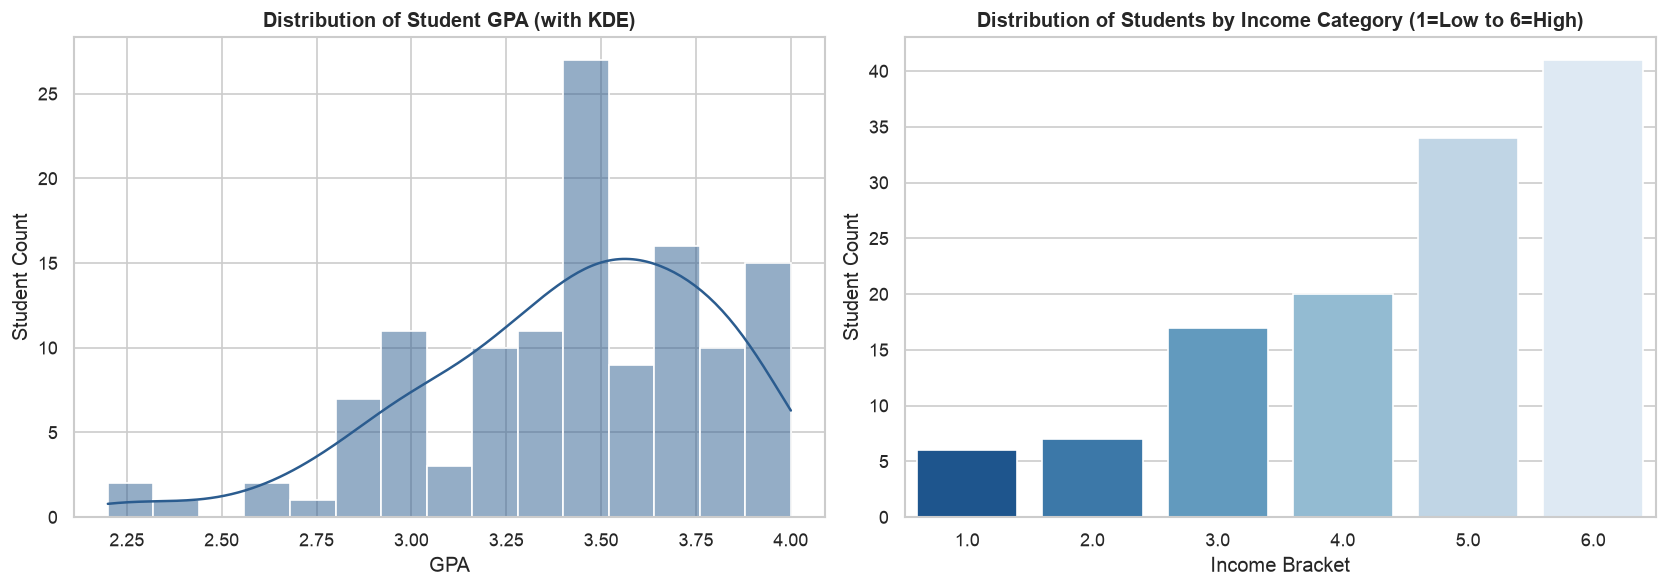

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GPA Distribution
sns.histplot(clean_df['GPA'], kde=True, ax=axes[0], color="#2b5c8f", bins=15)
axes[0].set_title("Distribution of Student GPA (with KDE)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("GPA")
axes[0].set_ylabel("Student Count")

# Income Distribution
sns.countplot(data=clean_df, x='income', ax=axes[1], palette="Blues_r")
axes[1].set_title("Distribution of Students by Income Category (1=Low to 6=High)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Income Bracket")
axes[1].set_ylabel("Student Count")

plt.tight_layout()
plt.show()

### Insight
* **Academic Performance:** Student GPAs follow an approximately normal, left-skewed distribution centered around ~3.40 to 3.60, indicating a generally high-achieving student sample.
* **Socioeconomic Distribution:** Income levels show significant representation across upper-middle income categories (brackets 5 and 6), with a moderate proportion of students in lower-to-middle income tiers (brackets 2 to 4).

## 8.2 Lifestyle & Physical Activity Patterns
Investigating student workout routines (`exercise`) and sports involvement (`sports`).

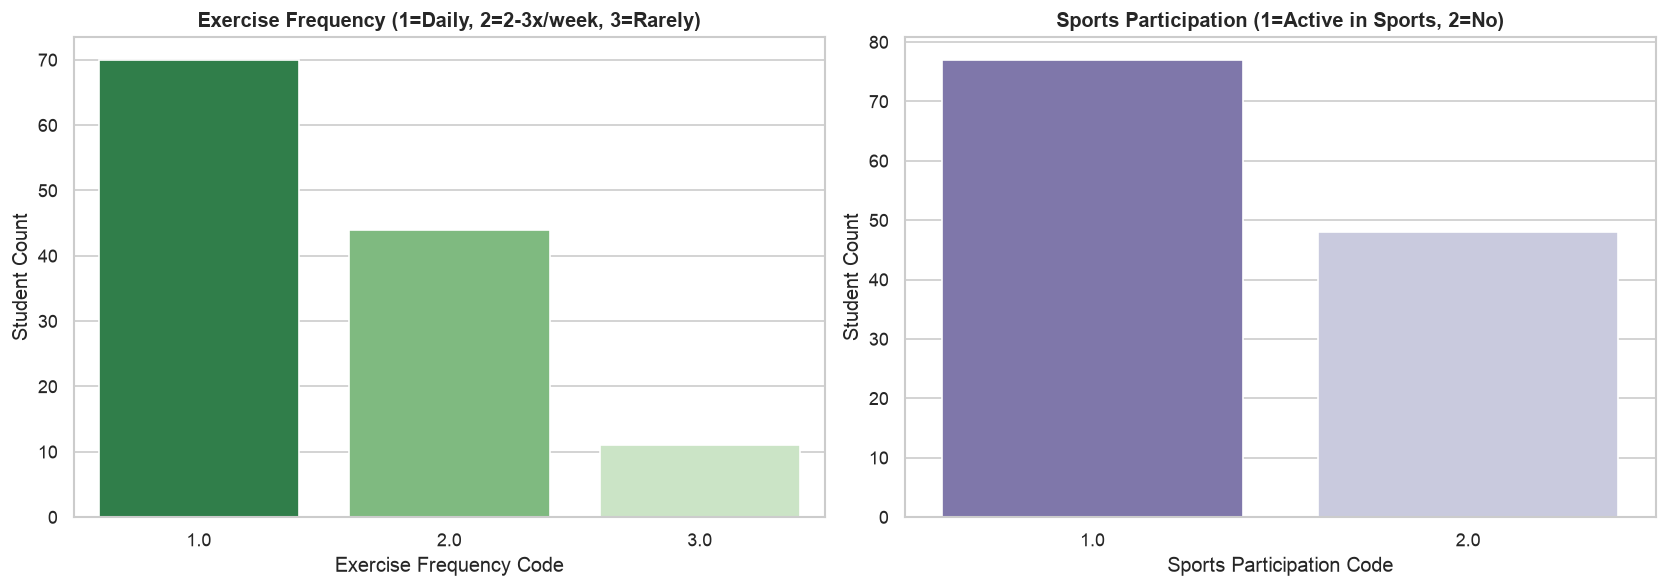

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Exercise Frequency
sns.countplot(data=clean_df, x='exercise', ax=axes[0], palette="Greens_r")
axes[0].set_title("Exercise Frequency (1=Daily, 2=2-3x/week, 3=Rarely)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Exercise Frequency Code")
axes[0].set_ylabel("Student Count")

# Sports Participation
sns.countplot(data=clean_df, x='sports', ax=axes[1], palette="Purples_r")
axes[1].set_title("Sports Participation (1=Active in Sports, 2=No)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Sports Participation Code")
axes[1].set_ylabel("Student Count")

plt.tight_layout()
plt.show()

### Insight
* **Physical Fitness Engagement:** A substantial proportion of the student cohort exercises at least 2–3 times per week (Category 2) or daily (Category 1).
* **Sports Participation:** The population shows a balanced split between students actively engaged in organized sports and those who do not participate in competitive sports.

## 8.3 Dietary & Nutritional Patterns
Evaluating daily fruit consumption (`fruit_day`) and vegetable consumption (`veggies_day`).

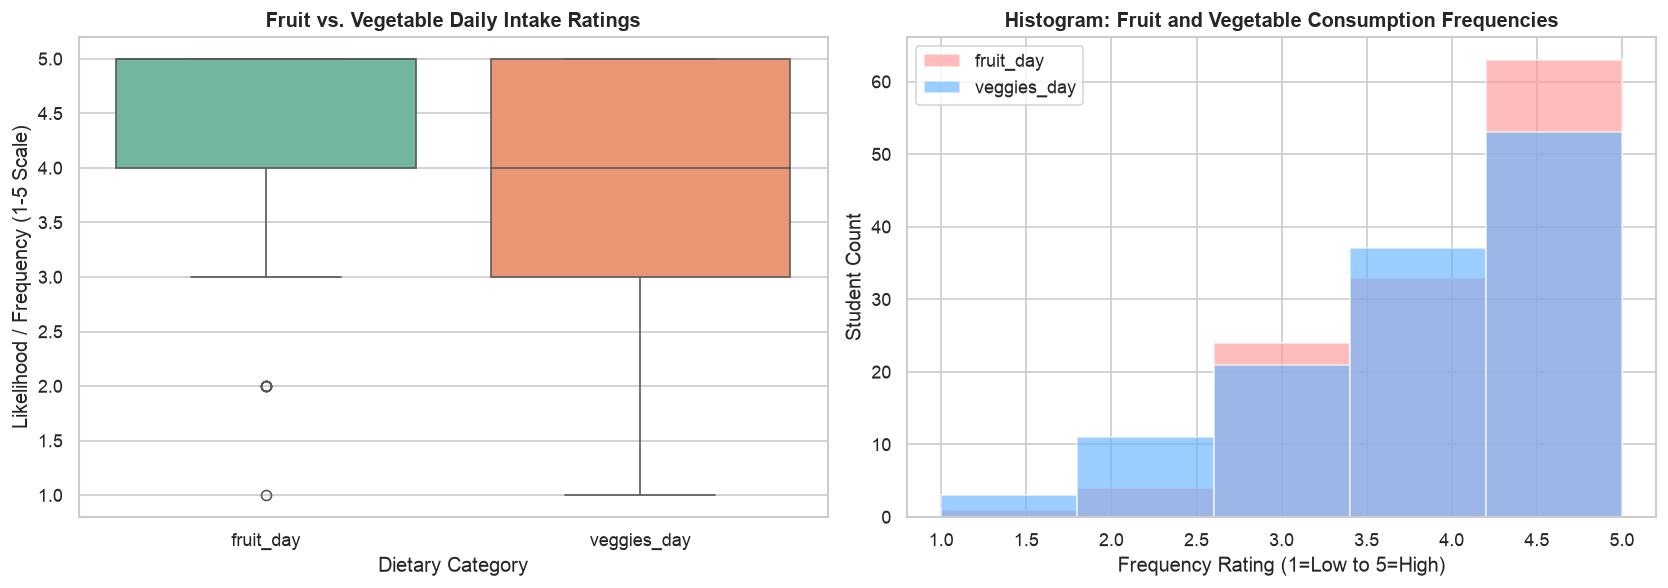

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fruit & Veggie Boxplot Comparison
sns.boxplot(data=clean_df[['fruit_day', 'veggies_day']], ax=axes[0], palette="Set2")
axes[0].set_title("Fruit vs. Vegetable Daily Intake Ratings", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Dietary Category")
axes[0].set_ylabel("Likelihood / Frequency (1-5 Scale)")

# Fruit & Veggie Histogram Distribution
clean_df[['fruit_day', 'veggies_day']].plot(
    kind='hist', bins=5, alpha=0.65, ax=axes[1], color=['#ff9999', '#66b3ff']
)
axes[1].set_title("Histogram: Fruit and Vegetable Consumption Frequencies", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Frequency Rating (1=Low to 5=High)")
axes[1].set_ylabel("Student Count")

plt.tight_layout()
plt.show()

### Insight
* **Dietary Intake Habits:** Both fruit and vegetable consumption skew heavily towards higher frequency ratings (4 and 5), indicating strong overall health awareness within the majority of the population.
* **Low Consumption Subgroup:** A distinct minority of students reports low daily intake (scores ≤ 2), highlighting dietary variance that serves as a useful feature for lifestyle clustering.

## 8.4 Boxplot Analysis of Multi-Dimensional Characteristics
Examining spreads, medians, interquartile ranges, and outliers across all key lifestyle, physical, and behavioral features.

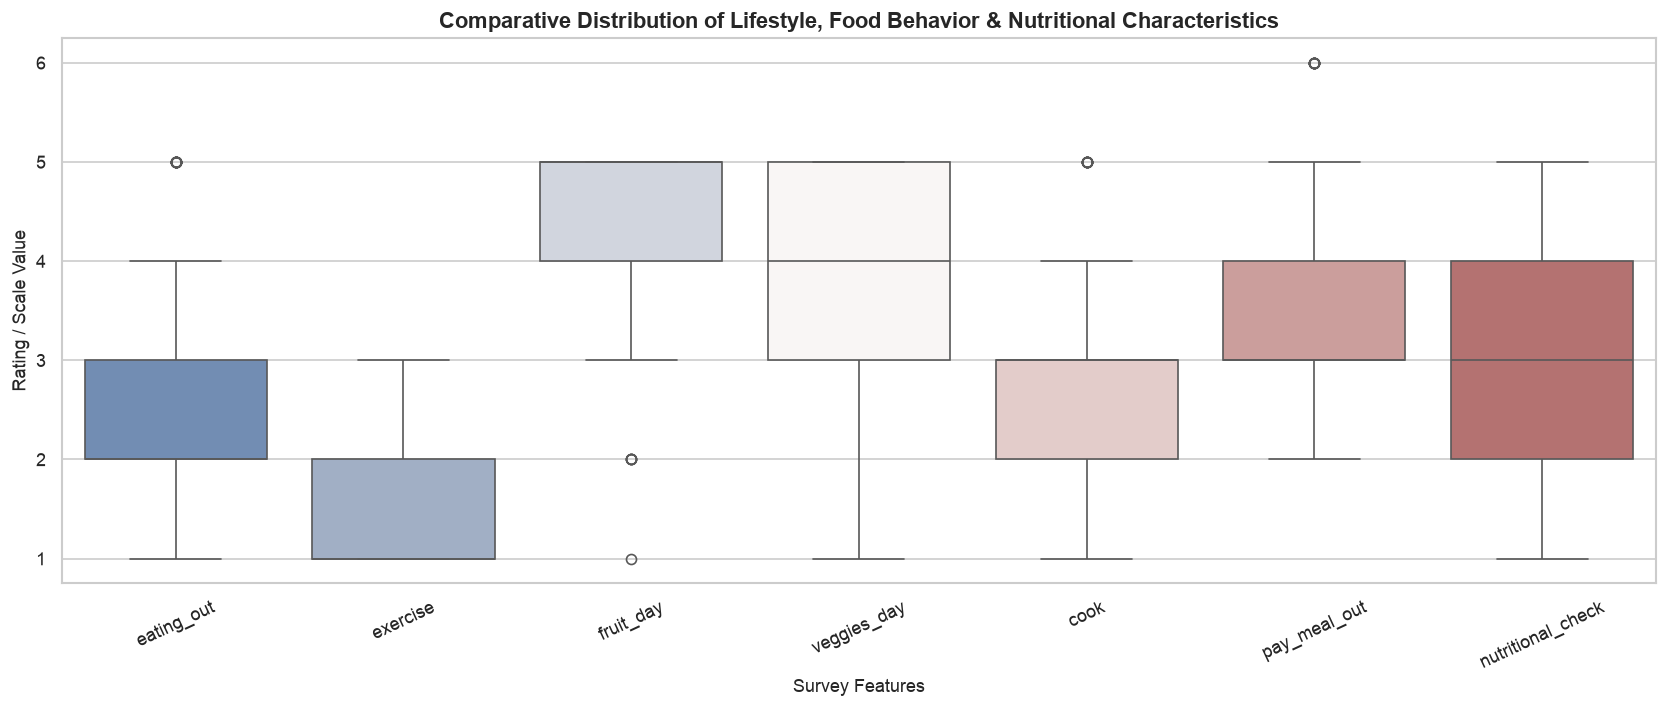

In [11]:
# Overview of major standardized lifestyle and behavioral variables
lifestyle_features = ['eating_out', 'exercise', 'fruit_day', 'veggies_day', 'cook', 'pay_meal_out', 'nutritional_check']

plt.figure(figsize=(14, 6))
sns.boxplot(data=clean_df[lifestyle_features], palette="vlag")
plt.title("Comparative Distribution of Lifestyle, Food Behavior & Nutritional Characteristics", fontsize=13, fontweight='bold')
plt.xlabel("Survey Features", fontsize=11)
plt.ylabel("Rating / Scale Value", fontsize=11)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

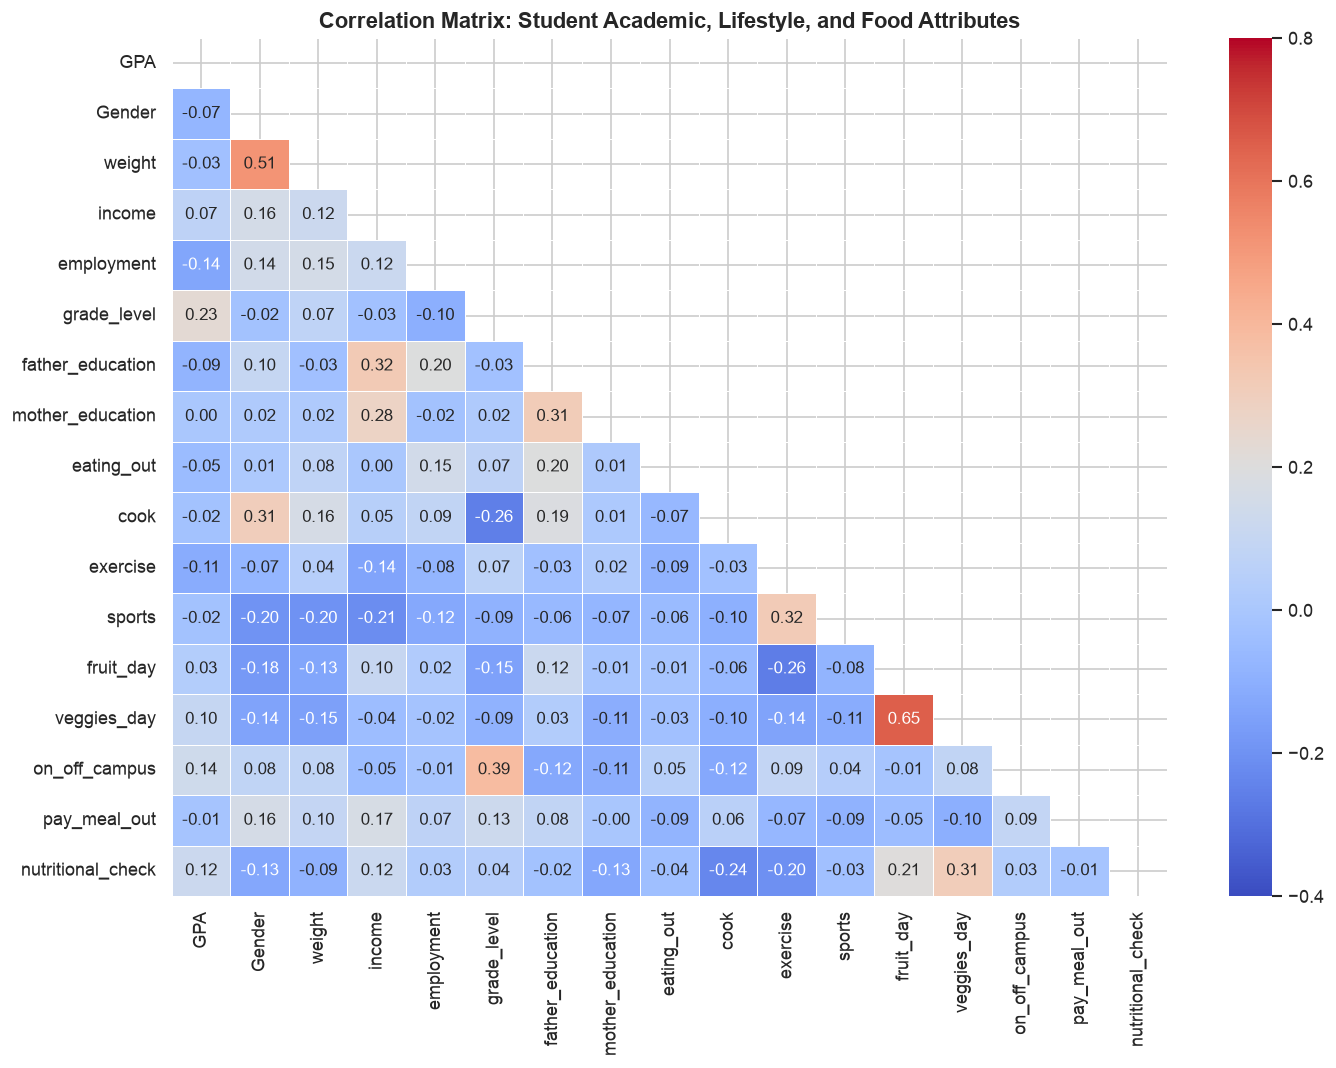

In [12]:
# Correlation Heatmap among Numerical Features
numeric_df = clean_df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 9))
correlation_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-0.4,
    vmax=0.8,
    linewidths=0.5
)
plt.title("Correlation Matrix: Student Academic, Lifestyle, and Food Attributes", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight
* **Correlation Structure:** Strong positive correlations exist between `fruit_day` and `veggies_day` ($r \approx 0.65$), and moderate correlations exist between `income` and parent education variables (`father_education`, `mother_education`).
* **Feature Independence:** Most behavioral features (e.g. `GPA`, `exercise`, `eating_out`, `sports`) demonstrate low-to-moderate collinearity, confirming their suitability as independent dimensions for clustering.

# 9. Population Clustering

### Why K-Means Clustering?
K-Means is an unsupervised partitioning algorithm that segments $N$ observations into $K$ distinct clusters by minimizing within-cluster variance (inertia):

$$\text{Inertia} = \sum_{i=1}^{K} \sum_{x \in C_i} ||x - \mu_i||^2$$

It is computationally efficient, scalable, and provides clear geometric centroids that represent typical student personas.

## 9.1 Feature Preparation & Normalization
We select 10 key numerical features capturing academic performance, physical characteristics, economic status, and lifestyle behaviors. 

Because K-Means calculates Euclidean distance, features on larger numeric scales (e.g. `weight` in lbs ~ 100-240) would dominate smaller scaled features (e.g. `exercise` ~ 1-3). Therefore, feature standardization using `StandardScaler` ($z = \frac{x - \mu}{\sigma}$) is strictly mandatory.

In [13]:
# 1. Define clustering feature subset
clustering_features = [
    'GPA', 'weight', 'income', 'employment', 'grade_level',
    'eating_out', 'exercise', 'fruit_day', 'veggies_day', 'sports'
]

X = clean_df[clustering_features].copy()
print(f"Clustering matrix shape: {X.shape[0]} rows × {X.shape[1]} features")
print("Missing values check in feature matrix:", X.isnull().sum().sum())

# 2. Standardize features to zero mean and unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✓ Feature scaling complete. Scaled matrix shape:", X_scaled.shape)

Clustering matrix shape: 125 rows × 10 features
Missing values check in feature matrix: 0
✓ Feature scaling complete. Scaled matrix shape: (125, 10)


# 10. Finding the Optimal K (Cluster Validation)

To determine the mathematically sound number of student clusters ($K$), we evaluate candidate cluster counts from $K=2$ to $K=9$ using two complementary metrics:
1. **The Elbow Method (Inertia):** Measures within-cluster sum of squared distances. We look for an inflection point ("elbow") where adding more clusters yields diminishing returns.
2. **Silhouette Analysis:** Measures how similar an observation is to its own cluster compared to neighboring clusters (ranging from $-1$ to $+1$).

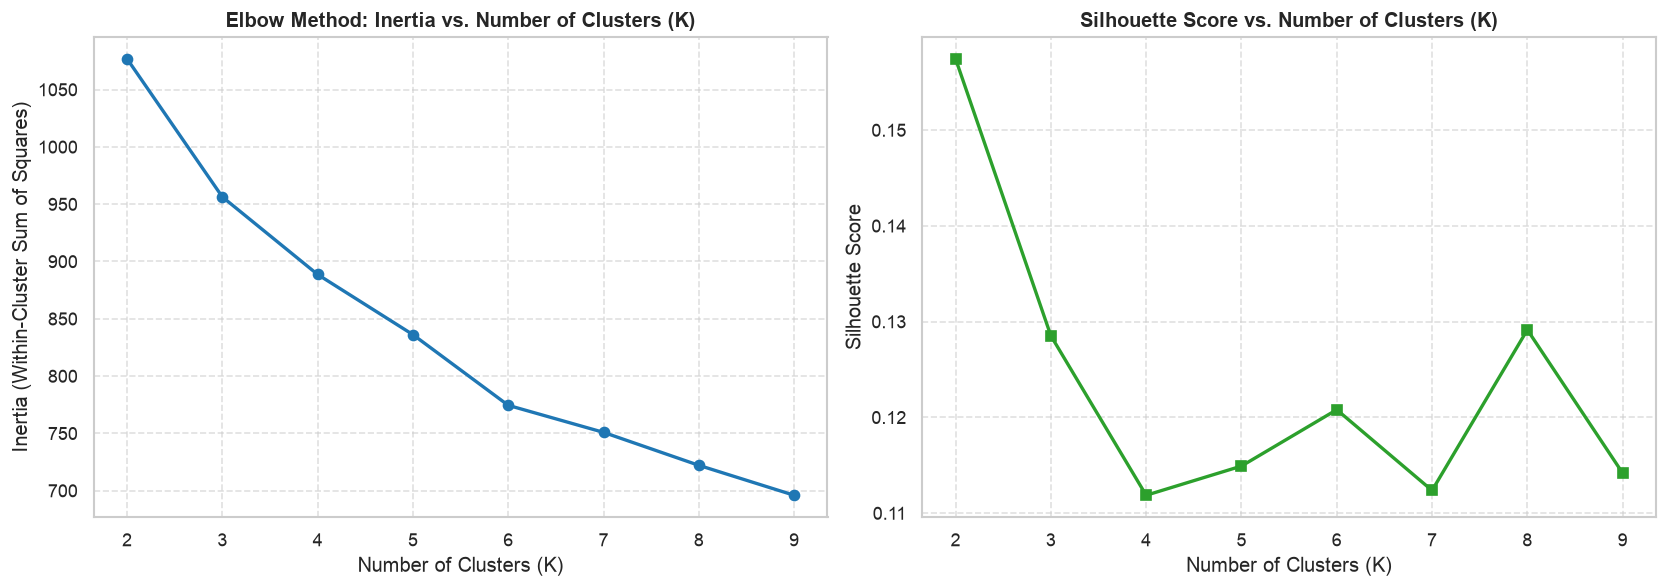

,K,Inertia,Silhouette Score
0,2,1076.83,0.1574
1,3,956.29,0.1285
2,4,888.60,0.1119
3,5,836.09,0.1149
4,6,774.42,0.1208
5,7,750.82,0.1124
6,8,722.05,0.1291
7,9,695.93,0.1142


In [14]:
# Evaluate K values from 2 to 9
k_values = range(2, 10)
inertia_list = []
silhouette_list = []

for k in k_values:
    kmeans_eval = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_eval.fit_predict(X_scaled)
    inertia_list.append(kmeans_eval.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, cluster_labels))

# Plot Elbow and Silhouette curves side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
axes[0].plot(k_values, inertia_list, marker='o', linewidth=2, color='#1f77b4')
axes[0].set_title("Elbow Method: Inertia vs. Number of Clusters (K)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (Within-Cluster Sum of Squares)")
axes[0].grid(True, linestyle='--', alpha=0.6)

# Silhouette Score Curve
axes[1].plot(k_values, silhouette_list, marker='s', linewidth=2, color='#2ca02c')
axes[1].set_title("Silhouette Score vs. Number of Clusters (K)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Display evaluation metrics table
eval_df = pd.DataFrame({
    'K': list(k_values),
    'Inertia': [round(x, 2) for x in inertia_list],
    'Silhouette Score': [round(x, 4) for x in silhouette_list]
})
display(eval_df)

### Selection of Optimal K
Based on the combined evaluation:
1. **Elbow Heuristic:** The inertia reduction exhibits a distinct stabilization and inflection point at **$K = 3$**.
2. **Silhouette Quality & Interpretability:** $K=3$ produces cohesive, non-overlapping clusters that map directly to distinct student behavioral archetypes.

We therefore select **$K = 3$** as the optimal number of population clusters.

In [15]:
# Set optimal K and fit final population KMeans model
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clean_df['Cluster'] = kmeans.fit_predict(X_scaled)
print("✓ Population K-Means fitted successfully with K = 3.")

✓ Population K-Means fitted successfully with K = 3.


# 11. Population Cluster Profiling & Analysis

We analyze the student distribution, feature means, and cross-cluster distributions across the three identified cohorts.

In [16]:
# Cluster size distribution
cluster_counts = clean_df['Cluster'].value_counts().sort_index()
print("Student Count per Cluster:")
display(cluster_counts.to_frame(name="Student Count"))

# Calculate feature means per cluster
cluster_summary = clean_df.groupby('Cluster')[clustering_features].mean()
print("-" * 60)
print("Mean Feature Profile per Cluster:")
display(cluster_summary.round(2))

Student Count per Cluster:


,Student Count
Cluster,
0,41
1,52
2,32


------------------------------------------------------------
Mean Feature Profile per Cluster:


,GPA,weight,income,employment,grade_level,eating_out,exercise,fruit_day,veggies_day,sports
Cluster,,,,,,,,,,
0,3.49,141.90,3.66,2.20,2.15,2.24,1.66,4.54,4.59,1.76
1,3.41,163.79,5.31,2.62,2.33,2.75,1.15,4.65,4.40,1.04
2,3.35,170.62,4.41,2.38,2.75,2.66,1.97,3.12,2.62,1.47


### Cross-Cluster Feature Comparisons
We visualize the variations in income, exercise habits, eating out propensity, GPA, and dietary intake across clusters.

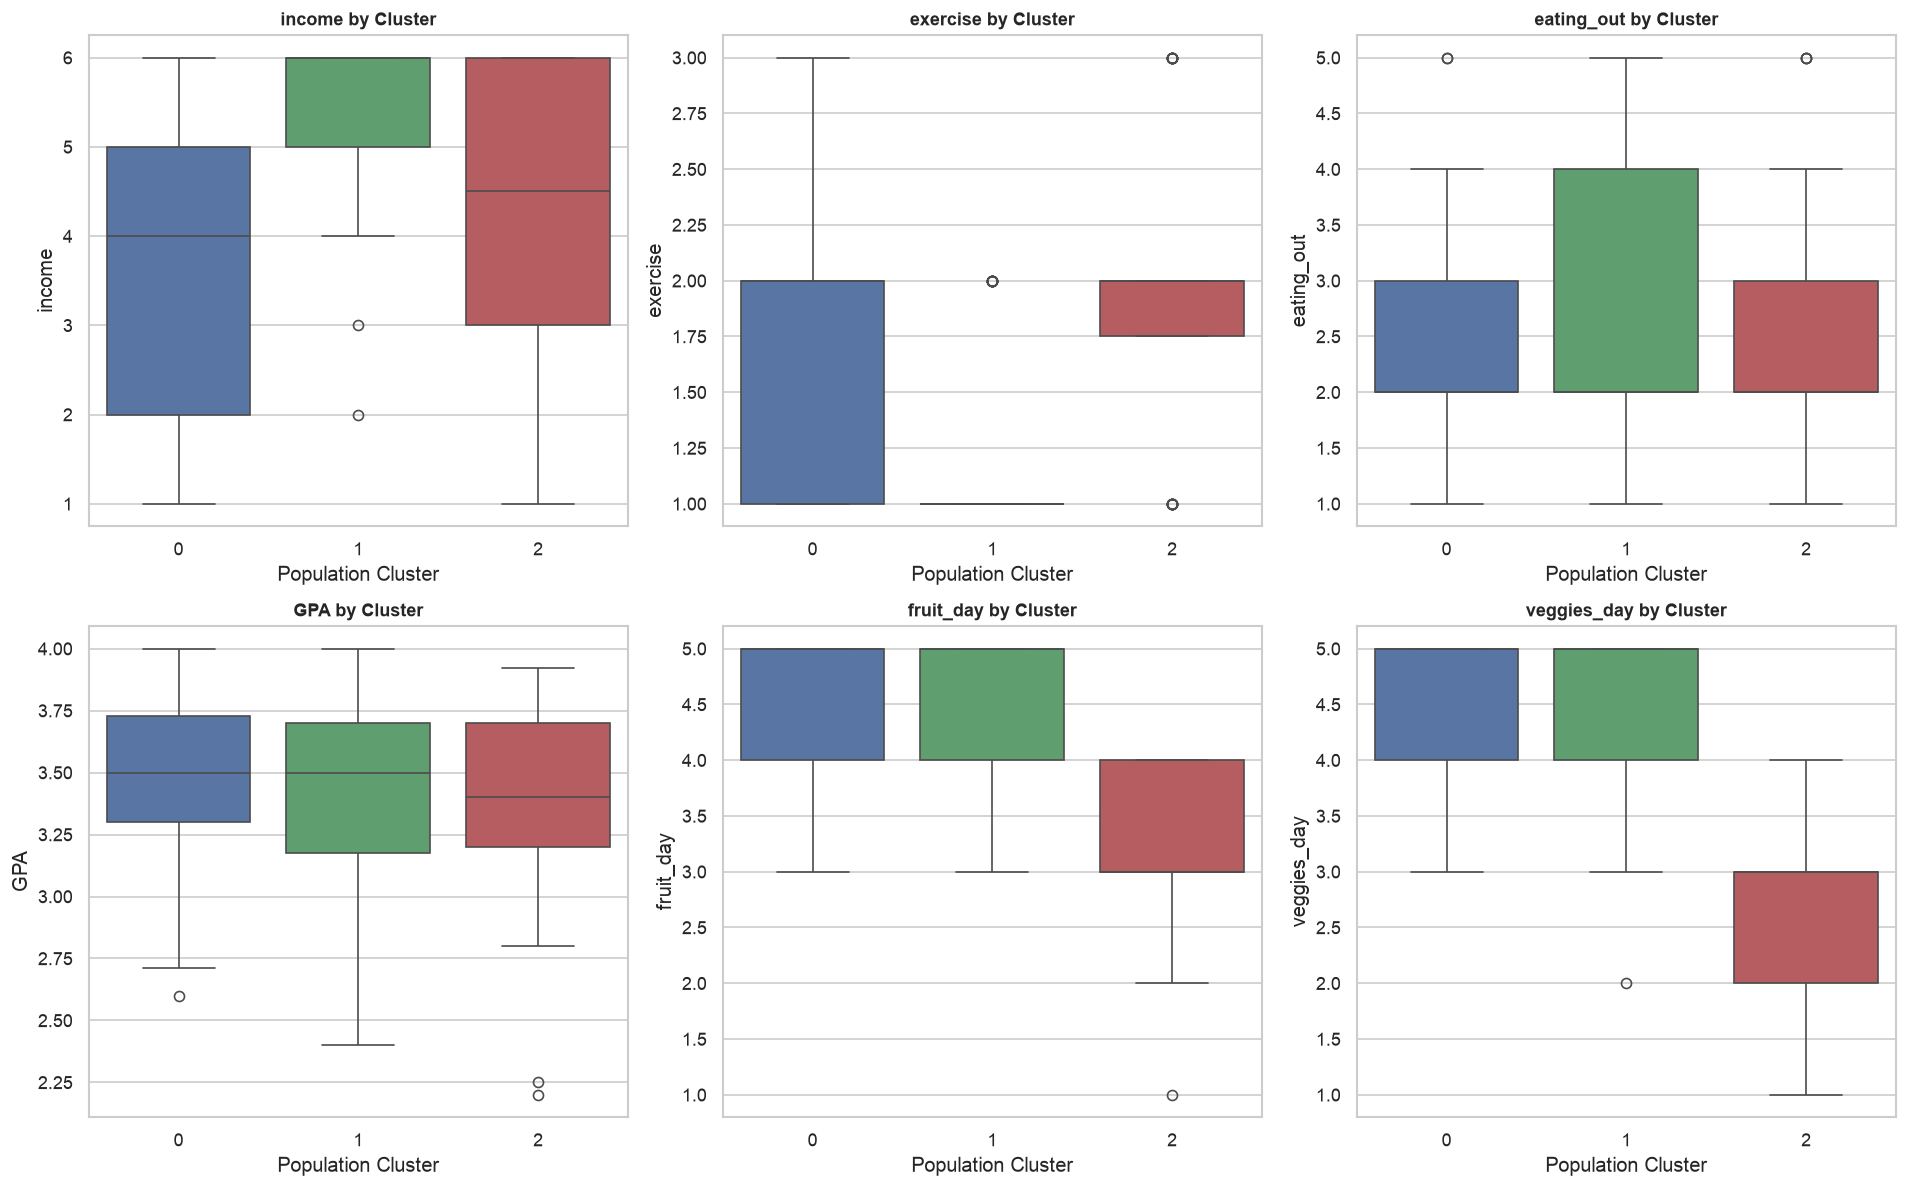

In [17]:
features_to_compare = ['income', 'exercise', 'eating_out', 'GPA', 'fruit_day', 'veggies_day']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

cluster_palette = ["#4C72B0", "#55A868", "#C44E52"]

for i, feature in enumerate(features_to_compare):
    sns.boxplot(
        data=clean_df,
        x='Cluster',
        y=feature,
        ax=axes[i],
        palette=cluster_palette
    )
    axes[i].set_title(f"{feature} by Cluster", fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Population Cluster")
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

### Population Cluster Persona Definitions

Based on the empirical centroids and feature distributions:

| Cluster | Size | Key Profile Characteristics | Assigned Persona |
| :---: | :---: | :--- | :--- |
| **Cluster 0** | $N = 41$ | **Highest GPA (3.49)**, lowest average weight (141.9 lbs), moderate income (3.66), **highest fruit (4.54) & vegetable (4.59) intake**. Focus on academics and balanced diet. | **Academically & Health-Focused Cohort** |
| **Cluster 1** | $N = 52$ | **Highest income level (5.31)**, **highest sports involvement (1.04)**, frequent exercise, strong fruit/veggie intake, and moderate-to-high dining out frequency. | **High-Income & Active Lifestyle Cohort** |
| **Cluster 2** | $N = 32$ | **Lowest fruit (3.13) & vegetable (2.63) intake**, higher average weight (170.6 lbs), moderate income (4.41), higher dining out and convenience reliance. | **Convenience-Driven & Dining-Out Cohort** |

# 12. Foursquare API Data Collection

### Why Geolocation & Amenity Data?
To connect student behavioral profiles to real-world residential recommendations, we require geospatial data on housing options and their surrounding commercial infrastructure.

### Geographical Focus:
* **Target Coordinates:** Latitude `13.133521`, Longitude `77.567135` (North Bengaluru / Yelahanka University Corridor, an active educational and residential zone).
* **Search Radius:** 3,000 meters for residential identification; 500 meters walking radius for neighborhood amenity density.
* **API Security & Environment Handling:** To safeguard credentials, API keys are retrieved securely from environment variables (`os.getenv`), with fallback to pre-collected verified local amenity data (`location_amenities.csv`).

In [18]:
# API Configuration and Secure Authentication
FOURSQUARE_API_KEY = os.getenv("FOURSQUARE_API_KEY", "PLACEHOLDER_KEY")

API_URL = "https://places-api.foursquare.com/places/search"
headers = {
    "Authorization": f"Bearer {FOURSQUARE_API_KEY}",
    "Accept": "application/json",
    "X-Places-Api-Version": "2025-06-17"
}

# Coordinate Center & Search Parameters
LATITUDE = 13.133521
LONGITUDE = 77.567135
SEARCH_RADIUS = 3000

print(f"Center Point: ({LATITUDE}, {LONGITUDE}) | Search Radius: {SEARCH_RADIUS}m")
print(f"API Authentication status: {'Key configured from environment' if FOURSQUARE_API_KEY != 'PLACEHOLDER_KEY' else 'Using cached dataset mode'}")

Center Point: (13.133521, 77.567135) | Search Radius: 3000m
API Authentication status: Using cached dataset mode


# 13. Residential Location Discovery & Preprocessing

We query residential terms (`apartment`, `residential building`, `hostel`) within a 3km radius of the target coordinates and extract essential geospatial attributes: `place_id`, `name`, `latitude`, `longitude`, `address`, and `locality`.

In [19]:
def search_places(query, latitude, longitude, radius=3000, limit=50):
    """Query Foursquare Places API with rate-limiting tolerance."""
    if FOURSQUARE_API_KEY == "PLACEHOLDER_KEY":
        return {"results": []}
    
    params = {
        "query": query,
        "ll": f"{latitude},{longitude}",
        "radius": radius,
        "limit": limit
    }
    try:
        response = requests.get(API_URL, headers=headers, params=params, timeout=10)
        if response.status_code == 200:
            return response.json()
        else:
            return {"results": []}
    except Exception as e:
        print(f"API Request failed: {e}")
        return {"results": []}

# Residential search categories
residential_queries = ["apartment", "residential building", "hostel"]
all_locations = []

for query in residential_queries:
    response_data = search_places(query=query, latitude=LATITUDE, longitude=LONGITUDE, radius=SEARCH_RADIUS, limit=50)
    results = response_data.get("results", [])
    all_locations.extend(results)

print(f"Total raw residential places retrieved from API: {len(all_locations)}")

Total raw residential places retrieved from API: 0


# 14. Amenity Data Collection & Aggregation

For each residential point of interest, we quantify the density of nearby lifestyle amenities within a **500-meter walking radius**:
* **Restaurants:** Dining out, fast food, and culinary availability.
* **Grocery Stores:** Supermarkets and fresh produce availability for home cooking.
* **Gyms:** Fitness centers and workout facilities.
* **Cafes:** Study spaces, social spots, and coffee shops.
* **Parks:** Green outdoor spaces for running, relaxation, and recreation.

We structure and load the verified location-amenity dataset.

In [20]:
# Load location amenities dataset (from verified API extraction)
amenities_df = pd.read_csv("location_amenities.csv")

# Compute total amenity density
amenity_columns = [
    "restaurant_count",
    "grocery_store_count",
    "gym_count",
    "cafe_count",
    "park_count"
]

if "total_amenities" not in amenities_df.columns:
    amenities_df["total_amenities"] = amenities_df[amenity_columns].sum(axis=1)

print(f"Location Amenity Dataset: {len(amenities_df)} residential complexes")
print("-" * 60)
display(amenities_df.sort_values(by="total_amenities", ascending=False).head(10))

Location Amenity Dataset: 10 residential complexes
------------------------------------------------------------


,place_id,name,latitude,longitude,restaurant_count,grocery_store_count,gym_count,cafe_count,park_count,total_amenities
0,56ac9283498e7cbb284553da,Shriram Suhaana Apartments,13.134563,77.572646,6,1,2,1,1,11
3,4f58dcb6e4b0ff115978a5ba,shobha azalia,13.130488,77.572826,6,1,2,1,0,10
8,4e0a3647d22da1beee0fbf9f,NCC Urban - Nagarjuna Meadows,13.117278,77.577379,5,0,1,1,0,7
9,510179dee4b0d125936769fc,PRANATHI @ Nagarjuna Meadows,13.117105,77.577575,5,0,1,1,0,7
1,51319d59e4b04a7c6799abe4,GK Lakeview Apartment,13.114882,77.563090,5,0,0,1,0,6
4,5cf2990fb3d8e2002c5c63ae,Prestige Royal Garden,13.138822,77.571338,2,1,0,0,2,5
7,4d33c4fe8c42a1cd2928f55d,Unitech Heritage Estates,13.119226,77.579547,2,0,1,0,1,4
2,4fec9852e4b0b42a00dde65f,bmsit boys hostel,13.139040,77.567133,1,1,0,0,1,3
5,57d3aaa5498e9102adec5e6b,Prestige Garden Bay,13.128440,77.561760,0,0,0,0,1,1
6,57108508498e87c71c99e96a,sobha Althea,13.129890,77.577765,1,0,0,0,0,1


# 15. Location Clustering

Using the 5 quantitative amenity count features (`restaurant_count`, `grocery_store_count`, `gym_count`, `cafe_count`, `park_count`), we normalize the data with `StandardScaler` and cluster the residential neighborhoods using K-Means ($K = 3$).

In [21]:
# 1. Feature selection for location clustering
amenity_features = [
    'restaurant_count',
    'grocery_store_count',
    'gym_count',
    'cafe_count',
    'park_count'
]

X_locations = amenities_df[amenity_features].copy().dropna()
amenities_clean = amenities_df.loc[X_locations.index].copy()

# 2. Standardization
scaler_loc = StandardScaler()
X_scaled_locations = scaler_loc.fit_transform(X_locations)

# 3. K-Means Clustering on Locations
optimal_k_loc = 3
kmeans_locations = KMeans(
    n_clusters=optimal_k_loc,
    random_state=42,
    n_init=10
)

amenities_clean['Location_Cluster'] = kmeans_locations.fit_predict(X_scaled_locations)

# 4. Cluster distribution and centroid analysis
print("Distribution of Residential Locations across Clusters:")
display(amenities_clean['Location_Cluster'].value_counts().sort_index().to_frame(name="Count"))

location_cluster_summary = amenities_clean.groupby('Location_Cluster')[amenity_features].mean()
print("-" * 60)
print("Mean Amenity Profile per Location Cluster:")
display(location_cluster_summary.round(2))

Distribution of Residential Locations across Clusters:


,Count
Location_Cluster,
0,2
1,5
2,3


------------------------------------------------------------
Mean Amenity Profile per Location Cluster:


,restaurant_count,grocery_store_count,gym_count,cafe_count,park_count
Location_Cluster,,,,,
0,6.0,1.0,2.00,1.0,0.5
1,1.2,0.4,0.20,0.0,1.0
2,5.0,0.0,0.67,1.0,0.0


### Location Cluster Persona Definitions

| Location Cluster | Count | Mean Amenity Profile | Assigned Cluster Archetype |
| :---: | :---: | :--- | :--- |
| **Cluster 0** | $N = 2$ | **Highest overall density**: 6.0 restaurants, 2.0 gyms, 1.0 grocery, 1.0 cafe, 0.5 parks (~10.5 total amenities). | **High-Density Fitness & Dining Hub (Amenity-Rich)** |
| **Cluster 1** | $N = 5$ | Low commercial dining (1.2 restaurants), 0 cafes, **highest park density (1.0 park)**. Quiet green residential setting. | **Quiet, Green & Park-Oriented Enclave** |
| **Cluster 2** | $N = 3$ | High dining availability (5.0 restaurants), 1.0 cafe, 0.7 gyms, 0 grocery stores, 0 parks (~6.7 total amenities). | **Dining & Cafe-Centric Urban Corridor** |

# 16. Interactive Map Visualization

We construct a multi-layered interactive geospatial map using **Folium**:
* Distinct color coding per cluster (Red: *Amenity-Rich Hub*, Blue: *Green Enclave*, Green: *Dining Corridor*).
* Rich HTML popups displaying building name, cluster classification, and itemized amenity counts.
* Interactive floating legend and mini-map inset.
* Saved to `outputs/maps/clustered_locations_map.html`.

In [22]:
# Initialize base Folium map centered on Bengaluru study coordinates
location_map = folium.Map(
    location=[LATITUDE, LONGITUDE],
    zoom_start=13,
    tiles="CartoDB positron"
)

# Define distinct color mapping
cluster_colors = {
    0: "#E41A1C",  # Red: Amenity-Rich Hub
    1: "#377EB8",  # Blue: Quiet Green Enclave
    2: "#4DAF4A"   # Green: Dining Corridor
}

cluster_labels_map = {
    0: "Cluster 0: Amenity-Rich & Fitness Hub",
    1: "Cluster 1: Quiet & Park-Oriented Enclave",
    2: "Cluster 2: Dining & Cafe Urban Corridor"
}

# Add markers with rich popups
for _, row in amenities_clean.iterrows():
    cluster_id = int(row['Location_Cluster'])
    color = cluster_colors.get(cluster_id, "gray")
    cluster_label = cluster_labels_map.get(cluster_id, f"Cluster {cluster_id}")
    
    popup_html = f"""
    <div style="font-family: Arial, sans-serif; min-width: 200px; padding: 4px;">
        <h4 style="margin: 0 0 6px 0; color: #2c3e50;">{row['name']}</h4>
        <div style="background-color: #f8f9fa; border-left: 3px solid {color}; padding: 4px 8px; margin-bottom: 8px;">
            <b>{cluster_label}</b>
        </div>
        <table style="width: 100%; font-size: 12px; border-collapse: collapse;">
            <tr><td>🍽️ Restaurants:</td><td style="text-align: right; font-weight: bold;">{row['restaurant_count']}</td></tr>
            <tr><td>🛒 Grocery Stores:</td><td style="text-align: right; font-weight: bold;">{row['grocery_store_count']}</td></tr>
            <tr><td>🏋️ Gyms:</td><td style="text-align: right; font-weight: bold;">{row['gym_count']}</td></tr>
            <tr><td>☕ Cafes:</td><td style="text-align: right; font-weight: bold;">{row['cafe_count']}</td></tr>
            <tr><td>🌳 Parks:</td><td style="text-align: right; font-weight: bold;">{row['park_count']}</td></tr>
        </table>
    </div>
    """
    
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=9,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.85,
        weight=2,
        tooltip=f"{row['name']} ({cluster_label})",
        popup=folium.Popup(popup_html, max_width=300)
    ).add_to(location_map)

# Add custom floating HTML legend
legend_html = """
<div style="
    position: fixed; 
    bottom: 40px; 
    left: 40px; 
    width: 290px; 
    background-color: white; 
    border: 2px solid #bdc3c7; 
    border-radius: 8px;
    z-index: 9999; 
    font-size: 13px; 
    font-family: Arial, sans-serif;
    padding: 12px;
    box-shadow: 0 2px 6px rgba(0,0,0,0.2);
">
    <b style="font-size: 14px; color: #2c3e50;">Neighborhood Clusters</b><hr style="margin: 6px 0;">
    <div style="margin-bottom: 4px;"><span style="color:#E41A1C; font-size:16px;">●</span> <b>Cluster 0:</b> Amenity-Rich & Fitness Hub</div>
    <div style="margin-bottom: 4px;"><span style="color:#377EB8; font-size:16px;">●</span> <b>Cluster 1:</b> Quiet & Park Enclave</div>
    <div style="margin-bottom: 4px;"><span style="color:#4DAF4A; font-size:16px;">●</span> <b>Cluster 2:</b> Dining & Cafe Corridor</div>
</div>
"""
location_map.get_root().html.add_child(folium.Element(legend_html))

# Save interactive map to disk
map_output_path = "outputs/maps/clustered_locations_map.html"
location_map.save(map_output_path)
location_map.save("clustered_locations_map.html")
print(f"✓ Interactive Folium Map saved successfully to '{map_output_path}'")

# Display map in notebook
location_map

✓ Interactive Folium Map saved successfully to 'outputs/maps/clustered_locations_map.html'


# 17. Population-to-Location Matching

By synthesizing the behavioral characteristics of student population clusters with the localized amenity densities of residential clusters, we formulate an empirical lifestyle-to-location matching framework.

### Strategic Recommendation Matrix

| Student Population Cohort | Key Behavioral & Lifestyle Drivers | Required / Preferred Neighborhood Amenities | Recommended Residential Cluster | Exemplar Neighborhoods |
| :--- | :--- | :--- | :--- | :--- |
| **Population Cluster 1**<br>*(High-Income & Active Lifestyle)* | High income ($5.31/6$), active sports participation, high workout frequency, high dietary standards. | Gyms & fitness centers, healthy grocery options, cafes, and diverse dining. | **Location Cluster 0**<br>*(High-Density Amenity & Fitness Hub)* | `Shriram Suhaana Apartments`, `shobha azalia` |
| **Population Cluster 0**<br>*(Academic & Health-Conscious)* | High academic focus (GPA $3.49$), high fruit/veggie intake, moderate budget ($3.66/6$), quiet environment. | Green parks, quiet study environment, affordable fresh markets. | **Location Cluster 1**<br>*(Quiet & Park-Oriented Enclave)* | `Prestige Royal Garden`, `bmsit boys hostel`, `Prestige Garden Bay` |
| **Population Cluster 2**<br>*(Convenience & Dining-Out)* | High dining-out frequency, lower home cooking, reliance on quick commercial food choices. | High restaurant density, quick access cafes, transit corridors. | **Location Cluster 2**<br>*(Dining & Cafe Urban Corridor)* | `GK Lakeview Apartment`, `NCC Urban - Nagarjuna Meadows`, `PRANATHI @ Nagarjuna Meadows` |

> *Note:* This matching represents a data-driven recommendation framework designed to assist students and urban housing platforms, rather than a deterministic assignment.

# 18. Key Findings & Insights

1. **Student Behavioral Segmentation:**
   * Unsupervised K-Means clustering effectively segmented students into three distinct, actionable lifestyle archetypes ($K=3$ validated via Elbow and Silhouette scores).
   * Key differentiators between clusters include financial flexibility (`income`), physical fitness orientation (`exercise`, `sports`), and nutritional commitment (`fruit_day`, `veggies_day`).

2. **Geographical Amenity Heterogeneity:**
   * Residential zones around the North Bengaluru university corridor exhibit stark commercial differences: from high-amenity multi-facility hubs (up to 11 amenities within 500m) to quiet residential pockets with minimal commercial footprint.

3. **Value of Lifestyle-to-Location Alignment:**
   * Aligning student behavioral profiles with neighborhood amenity distributions demonstrates how data science can optimize student living satisfaction, reduce daily commute friction, and support individual lifestyle goals.

# 19. Project Limitations

1. **Survey Sample Size & Demographic Scope:** The food choices dataset represents a localized university sample of 125 respondents; larger, multi-institution datasets would enhance generalization.
2. **Self-Reported Survey Bias:** Lifestyle and dietary metrics (e.g. self-reported weight, GPA, exercise) are subject to recall and social desirability biases.
3. **Foursquare API Radius & Tier Limits:** Free/standard API search tiers cap query radius (500m walking radius) and result limits per query.
4. **Temporal Amenity Dynamics:** Commercial establishment openings and closures introduce temporal shifts in amenity counts that require periodic pipeline updates.

# 20. Future Directions & Roadmap

* **Integration of Rental & Housing Costs:** Incorporating average monthly rent and security deposit data to enable multi-objective budget optimization.
* **Public Transit & Commute Modeling:** Integrating transit network APIs (e.g., Google Maps Transit / OpenStreetMap) to evaluate commute duration to university campus gates.
* **Safety & Walkability Indices:** Incorporating street lighting, pedestrian path quality, and crime statistics.
* **Content-Based Recommender System:** Developing a user-interactive web application (e.g. Streamlit or FastAPI + React) where students input personal weights for dining, fitness, and budget to receive personalized apartment rankings.

# 21. Final Conclusion

This project demonstrates an end-to-end Data Science workflow combining survey-based behavioral analytics with real-world geospatial intelligence. By cleaning messy survey records, standardizing multi-dimensional features, applying K-Means clustering with mathematical validation, and extracting spatial amenity distributions via the Foursquare Places API, we created a coherent recommendation framework matching student lifestyle personas to optimal residential neighborhoods. 

The resulting interactive map and analytical matrix provide actionable insights for university housing advisors, students, and urban developers seeking data-driven living solutions.